<a href="https://colab.research.google.com/github/YardenGoraly/Mujoco_fun/blob/main/MuJoCo_fun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Initial setup, you shouldn't have to modify this code

%pip install -qq mujoco
%pip install -qq mediapy

import platform
import os
import subprocess
import mediapy as media

# Detect the operating system and configure GPU rendering accordingly.
if platform.system() == "Linux":
    # Assume Nvidia GPU is present.
    if subprocess.run("nvidia-smi", shell=True).returncode != 0:
        raise RuntimeError(
            "Cannot communicate with GPU. Make sure you are using a GPU runtime."
        )

    # Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
    NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
    if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
        with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
            f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")
    print("Setting environment variable for Nvidia GPU rendering (EGL).")
    os.environ["MUJOCO_GL"] = "egl"

elif platform.system() == "Darwin":
    # Assume running on macOS (Apple Silicon).
    print("Running on macOS. Setting environment variable for GPU rendering using GLFW.")
    os.environ["MUJOCO_GL"] = "glfw"

    media.set_ffmpeg("/opt/homebrew/bin/ffmpeg")
else:
    print("Unsupported platform. GPU rendering might not be configured correctly.")

# Check if MuJoCo installation was successful.
try:
    import mujoco as mj
    mj.MjModel.from_xml_string("<mujoco/>")
except Exception as e:
    raise RuntimeError(
        "Something went wrong during MuJoCo installation. Check the shell output above for more information."
    ) from e

print("MuJoCo installation successful.")

# Other imports and helper functions.
import time
import itertools
import numpy as np
np.set_printoptions(precision=3, suppress=True, linewidth=100)

# Graphics and plotting.
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# On Linux, ensure ffmpeg is installed (this is not applicable on macOS).
if platform.system() == "Linux":
    !command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)

%pip install -q mediapy
import mediapy as media

from IPython.display import clear_output
clear_output()


In [2]:
#More setup 
%pip install -qq robot_descriptions
%pip install -qq dm_control

from robot_descriptions import panda_mj_description
from IPython.display import HTML
# this is loading from mujoco, one of the custom loaders of robot_descriptions
# the others are pybullet, iDynTree, Pinocchio, RoboMeshCat, yourdfpy
from robot_descriptions.loaders.mujoco import load_robot_description
from dm_control import mjcf
import dm_control
import PIL.Image


def display_video(frames, framerate=30):
    height, width, _ = frames[0].shape
    dpi = 70
    orig_backend = matplotlib.get_backend()
    matplotlib.use('Agg')  # Switch to headless 'Agg' to inhibit figure rendering.
    fig, ax = plt.subplots(1, 1, figsize=(width / dpi, height / dpi), dpi=dpi)
    matplotlib.use(orig_backend)  # Switch back to the original backend.
    ax.set_axis_off()
    ax.set_aspect('equal')
    ax.set_position([0, 0, 1, 1])
    im = ax.imshow(frames[0])
    def update(frame):
      im.set_data(frame)
      return [im]
    interval = 1000/framerate
    anim = animation.FuncAnimation(fig=fig, func=update, frames=frames,
                                   interval=interval, blit=True, repeat=False)
    return HTML(anim.to_html5_video())


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Get XML for Sawyer, hand, and ball
ball_xml = """
<mujoco model="ball">
    <worldbody>
        <body name="ball_body" pos="1.0 -0.2 0.95">
            <geom name="ball_geom" mass="0.01" friction="1.5" type="sphere" size="0.05" rgba="1 0 0 1"
                  solref="0.06 1" solimp="0.9 0.95 0.003 0.5 2"/>
        </body>
    </worldbody>
</mujoco>
"""

table_xml = """
<mujoco model="table">
    <worldbody>
        <body name="table_body" pos="1.0 -0.2 0.45">
            <geom name="table_geom" mass="200000" friction="0.8" type="box" solref="0.01 0.5" size="0.3 0.6 0.45" rgba="0.798 0.71 0.469 1"/>
        </body>
    </worldbody>
</mujoco>
"""

hand_path = "mujoco_menagerie/wonik_allegro/right_hand.xml"
sawyer_path = "mujoco_menagerie/rethink_robotics_sawyer/sawyer.xml"

In [4]:
# Define Models
hand_model = mjcf.from_path(hand_path)
sawyer_model = mjcf.from_path(sawyer_path)
ball_model = mjcf.from_xml_string(ball_xml)
table_model = mjcf.from_xml_string(table_xml)

ball_geom = ball_model.find('geom', 'ball_geom')
print(ball_geom.name)   # ball_geom

# Fingertips in XML are not actually at the tip, so we add a body with an offset
ff_tip = hand_model.find('body', 'ff_tip')
ff_tip.add('body', name='ff_tip_rubber', pos=[0, 0, 0.028])
hand_model.find('body', 'ff_tip_rubber').add('geom', type='sphere', size=[0.012], rgba=[0, 0, 0, 0])
mf_tip = hand_model.find('body', 'mf_tip')
mf_tip.add('body', name='mf_tip_rubber', pos=[0, 0, 0.028])
hand_model.find('body', 'mf_tip_rubber').add('geom', type='sphere', size=[0.012], rgba=[0, 0, 0, 0])
rf_tip = hand_model.find('body', 'rf_tip')
rf_tip.add('body', name='rf_tip_rubber', pos=[0, 0, 0.028])
hand_model.find('body', 'rf_tip_rubber').add('geom', type='sphere', size=[0.012], rgba=[0, 0, 0, 0])
th_tip = hand_model.find('body', 'th_tip')
th_tip.add('body', name='th_tip_rubber', pos=[0, 0, 0.044])
hand_model.find('body', 'th_tip_rubber').add('geom', type='sphere', size=[0.012], rgba=[0, 0, 0, 0])

ball_geom


MJCF Element: <geom type="sphere" size="0.012" rgba="0 0 0 0"/>

In [5]:
# Attach hand to the Sawyer
arena = mjcf.RootElement()
sawyer_site = sawyer_model.find('site', 'attachment_site')
attachment_frame = arena.attach(ball_model)
arena.attach(table_model)
sawyer_site.attach(hand_model)
arena.attach(sawyer_model)

# Set up scene
sky = arena.asset.add('texture', type='skybox', builtin="gradient", rgb1=[0, .2, 1], 
                      rgb2="1 1 1", width=512, height=512)
chequered = arena.asset.add('texture', type='2d', builtin='checker', width=500,
                            height=500, rgb1=[.2, .3, .4], rgb2=[.3, .4, .5])
grid = arena.asset.add('material', name='grid', texture=chequered,
                       texrepeat=[30, 30], reflectance=.1)
arena.worldbody.add('geom', type='plane', size=[10, 10, 10], material=grid)
for x in [-2, 2]:
  arena.worldbody.add('light', pos=[x, -1, 3], dir=[-x, 1, -2])
for y in [-2, 2]:
  arena.worldbody.add('light', pos=[-1, y, 3], dir=[1, -y, -2], attenuation=[3, 0, 0], castshadow=False)
arena.worldbody.add('camera', name='camera_1', pos=[-1, -1, 0.3], euler=[1.55, 2, 0])

# Add freejoint to ball so it can move freely
attachment_frame.add('joint', name='ball_joint', type='free', armature='5e-5')

# Extract ball elements to read attributes
ball_body = ball_model.find('body', 'ball_body')
ball_geom = ball_model.find('geom', 'ball_geom')

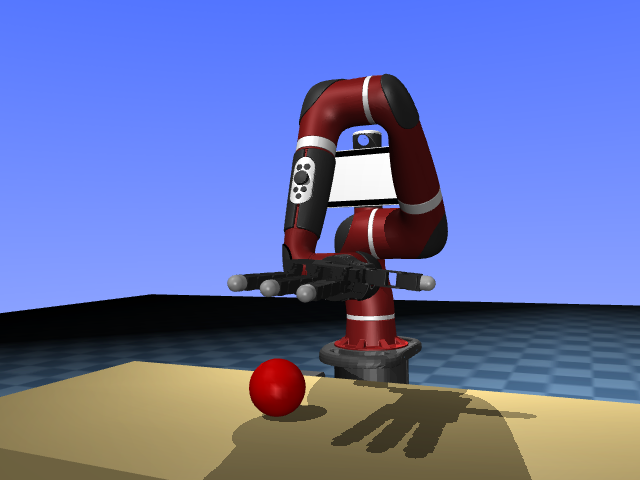

In [6]:
def set_camera_position(physics, camera_name, camera_position):
    camera_id = physics.model.name2id(camera_name, "camera")
    physics.named.model.cam_pos[camera_name] = camera_position
    return camera_id

def set_initial_configuration():
    initial_qpos = [0, 0, 0, 0, 0, 0, 0, 0, -0.8, 0, 2, 0, -1.2, 3.2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    physics.data.qpos[:] = initial_qpos

physics = mjcf.Physics.from_mjcf_model(arena)

# Init scene
camera_id1 = set_camera_position(physics, "camera_1", [1.9, 0.3, 1.2])
set_initial_configuration()

physics.forward()
PIL.Image.fromarray(physics.render(height=480, width=640, camera_id=camera_id1))

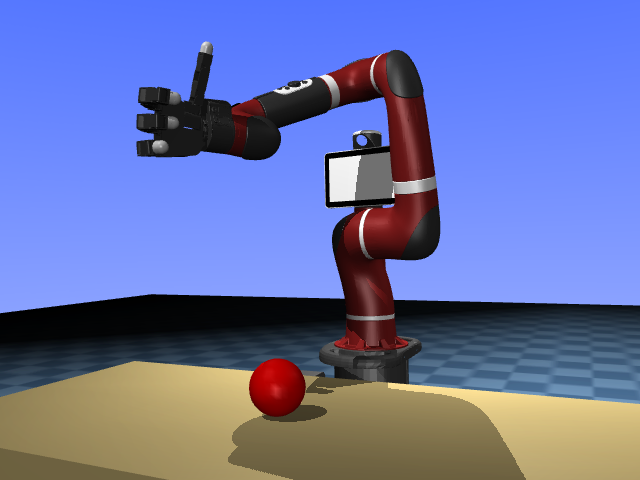

In [7]:
# Task 1:
import importlib
import multifingered_ik

importlib.reload(multifingered_ik)

from multifingered_ik import LevenbergMarquardtIK

def evaluate_IK(physics, target_positions, target_orientations, target_names):
    """
    This function evaluates the IK solver for the target bodies.
    """
    model = physics.model
    data = physics.data
    step_size = 0.5
    tol = 0.002
    alpha = 0.5
    n = len(target_positions)
    jacp = np.zeros((n, 3, model.nv)) #translational Jacobian
    jacr = np.zeros((n, 3, model.nv)) #rotational Jacobian
    damping = 0.15
    max_steps = 200

    ik = LevenbergMarquardtIK(model, data, step_size, tol, alpha, jacp, jacr, damping, max_steps, physics)
    final_qpos = ik.calculate(target_positions, target_orientations, target_names)
    return final_qpos

# YOUR CODE HERE: Fill these in from lab doc
target_positions = [
    [1.0139, -0.4455, 1.4342], 
    [1.0566, -0.3681, 1.4689], 
    [1.0564, -0.3731, 1.4255], 
    [1.0765, -0.3651, 1.3784], 
    [0.9403, -0.4003, 1.6041]
]

target_orientations = [
    [-0.62, -0.588, -0.3918, -0.3287], 
    [0.3301, 0.305, -0.6762, -0.5838], 
    [0.3465, 0.2863, -0.6522, -0.6104], 
    [0.0174, -0.0705, -0.7239, -0.686],
    [-0.9672, 0.061, 0.0294, 0.2446]
]

target_names = [
    'sawyer/allegro_right/palm', 
    'sawyer/allegro_right/ff_tip_rubber',
    'sawyer/allegro_right/mf_tip_rubber', 
    'sawyer/allegro_right/rf_tip_rubber',
    'sawyer/allegro_right/th_tip_rubber'
]

physics.reset()
final_qpos = evaluate_IK(physics, target_positions, target_orientations, target_names)
physics.data.qpos[:] = final_qpos
physics.forward()
PIL.Image.fromarray(physics.render(height=480, width=640, camera_id=camera_id1))

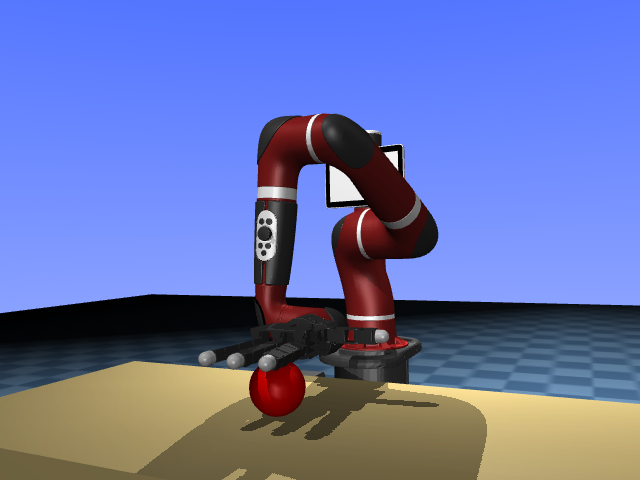

In [8]:
# Task 2:
# Note: your solution to task 1 must be correct for this starter code to work

# Setting up initial hand configuration for grasp
physics.reset()
# Set palm target state
target_palm_position = ball_body.pos
target_palm_position[2] += 0.07
# target_palm_position[2] += 0.05
target_palm_position = target_palm_position.reshape(1, -1)
target_palm_orientation = np.array([[0.71, 0, 0.71, 0]])
target_name = ['sawyer/allegro_right/palm']

# Solve IK on palm
set_initial_configuration()
palm_qpos_IK = evaluate_IK(physics, target_palm_position, target_palm_orientation, target_name)
physics.data.qpos = palm_qpos_IK

# Instead of physics.data.qpos[14:] = 0
physics.data.qpos[14:] = 0  # keep this as base
# Spread ff, mf, rf by offsetting their base joint (joint 0 of each finger)
physics.data.qpos[14] = -0.3   # ff: splay left
physics.data.qpos[18] = 0.0    # mf: center
physics.data.qpos[22] = 0.3    # rf: splay right

physics.forward()
PIL.Image.fromarray(physics.render(height=480, width=640, camera_id=camera_id1))

In [ ]:
from AllegroHandEnv import AllegroHandEnvSphere
from grasp_synthesis import synthesize_grasp

# Run grasp synthesis algorithm and keep intermediate joint states for visualization
q_h_slice = slice(14, 30)
q_h_init = physics.data.qpos[q_h_slice]
object_name = 'ball/ball_geom'
ball_radius = ball_geom.size[0]
ball_center = np.array(ball_body.pos)

allegro_env = AllegroHandEnvSphere(physics, ball_center, ball_radius, q_h_slice, object_name)
fingertip_names = ['sawyer/allegro_right/ff_tip_rubber', 'sawyer/allegro_right/mf_tip_rubber', 'sawyer/allegro_right/rf_tip_rubber', 'sawyer/allegro_right/th_tip_rubber']
force_closure_q_h, grasp_history = synthesize_grasp(
    allegro_env,
    q_h_init,
    fingertip_names,
    return_history=True,
    max_iters=300,
    lr=0.5,
 )

print(f"Saved {len(grasp_history)} grasp states for formation video.")

Iter 0, objective=100.4653, improvement=0.0383
Iter 1, objective=100.4437, improvement=0.0216
Iter 2, objective=100.4212, improvement=0.0225
Iter 3, objective=100.3991, improvement=0.0221
Iter 4, objective=100.3786, improvement=0.0205
Iter 5, objective=100.3607, improvement=0.0179
Iter 6, objective=100.3460, improvement=0.0148
Iter 7, objective=100.3343, improvement=0.0117
Iter 8, objective=100.3254, improvement=0.0090
Iter 9, objective=100.3185, improvement=0.0069
Iter 10, objective=100.3130, improvement=0.0054
Iter 11, objective=100.3085, improvement=0.0045
Iter 12, objective=100.3045, improvement=0.0040
Iter 13, objective=100.3006, improvement=0.0039
Iter 14, objective=100.2967, improvement=0.0039
Iter 15, objective=100.2927, improvement=0.0040
Iter 16, objective=100.2885, improvement=0.0043
Iter 17, objective=100.2839, improvement=0.0046
Iter 18, objective=100.2790, improvement=0.0049
Iter 19, objective=100.2739, improvement=0.0052
Iter 20, objective=100.2684, improvement=0.0055
It

Traceback (most recent call last):
  File "/Users/meli/Desktop/Kevin/UCB/EECS 106B/eeca106b-project/project4a/grasp_synthesis.py", line 334, in optimize_necessary_condition
    sol = opti.solve()
          ^^^^^^^^^^^^
  File "/Users/meli/Desktop/Kevin/UCB/EECS 106B/eeca106b-project/.venv/lib/python3.12/site-packages/casadi/casadi.py", line 51396, in solve
    return _casadi.Opti_solve(self, *args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/function_internal.cpp:161: Error calling IpoptInterface::finalize for 'solver':
.../casadi/interfaces/ipopt/ipopt_interface.cpp:313: No such IPOPT option: print_time
Traceback (most recent call last):
  File "/Users/meli/Desktop/Kevin/UCB/EECS 106B/eeca106b-project/project4a/grasp_synthesis.py", line 334, in optimize_necessary_condition
    sol = opti.solve()
          ^^^^^^^^^^^^
  File "/Users/meli/Desktop/Kevin/UCB/EECS 106B/eeca106b-project/.venv

Q+ solver failed: RuntimeError: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/function_internal.cpp:161: Error calling IpoptInterface::finalize for 'solver':
.../casadi/interfaces/ipopt/ipopt_interface.cpp:313: No such IPOPT option: print_time
Q+ distance: 1000000.000000 (eps=1e-05)
Optimizing necessary condition (Q+ distance)...
G shape: (6, 128)
G rank: 6
G (first 3 cols):
[[-0.865 -1.046 -1.039]
 [ 0.103 -0.033 -0.363]
 [-0.701 -0.393 -0.198]
 [-0.008 -0.008 -0.018]
 [ 0.061  0.057  0.05 ]
 [ 0.019  0.017  0.006]]
G min: -1.1175e+00, max: 1.0942e+00, mean: -1.7434e-01
alpha0: [0.008 0.008 0.008 0.008 0.008]
Q+ solver failed: RuntimeError: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/function_internal.cpp:161: Error calling IpoptInterface::finalize for 'solver':
.../casadi/interfaces/ipopt/ipopt_interface.cpp:313: No such IPOPT option: print_time
Q+ distance: 1000000.000000 (eps=1e-05)
Optimizing necessa

Traceback (most recent call last):
  File "/Users/meli/Desktop/Kevin/UCB/EECS 106B/eeca106b-project/project4a/grasp_synthesis.py", line 334, in optimize_necessary_condition
    sol = opti.solve()
          ^^^^^^^^^^^^
  File "/Users/meli/Desktop/Kevin/UCB/EECS 106B/eeca106b-project/.venv/lib/python3.12/site-packages/casadi/casadi.py", line 51396, in solve
    return _casadi.Opti_solve(self, *args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/function_internal.cpp:161: Error calling IpoptInterface::finalize for 'solver':
.../casadi/interfaces/ipopt/ipopt_interface.cpp:313: No such IPOPT option: print_time
Traceback (most recent call last):
  File "/Users/meli/Desktop/Kevin/UCB/EECS 106B/eeca106b-project/project4a/grasp_synthesis.py", line 334, in optimize_necessary_condition
    sol = opti.solve()
          ^^^^^^^^^^^^
  File "/Users/meli/Desktop/Kevin/UCB/EECS 106B/eeca106b-project/.venv

Q+ solver failed: RuntimeError: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/function_internal.cpp:161: Error calling IpoptInterface::finalize for 'solver':
.../casadi/interfaces/ipopt/ipopt_interface.cpp:313: No such IPOPT option: print_time
Q+ distance: 1000000.000000 (eps=1e-05)
Optimizing necessary condition (Q+ distance)...
G shape: (6, 128)
G rank: 6
G (first 3 cols):
[[-0.868 -1.048 -1.04 ]
 [ 0.105 -0.032 -0.362]
 [-0.697 -0.388 -0.193]
 [-0.008 -0.008 -0.018]
 [ 0.061  0.057  0.05 ]
 [ 0.019  0.017  0.005]]
G min: -1.1175e+00, max: 1.0942e+00, mean: -1.7479e-01
alpha0: [0.008 0.008 0.008 0.008 0.008]
Q+ solver failed: RuntimeError: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/function_internal.cpp:161: Error calling IpoptInterface::finalize for 'solver':
.../casadi/interfaces/ipopt/ipopt_interface.cpp:313: No such IPOPT option: print_time
Q+ distance: 1000000.000000 (eps=1e-05)
Optimizing necessa

...

Q+ solver failed: RuntimeError: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/function_internal.cpp:161: Error calling IpoptInterface::finalize for 'solver':
.../casadi/interfaces/ipopt/ipopt_interface.cpp:313: No such IPOPT option: print_time
Q+ distance: 1000000.000000 (eps=1e-05)
Optimizing necessary condition (Q+ distance)...
G shape: (6, 128)
G rank: 6
G (first 3 cols):
[[-0.858 -1.042 -1.036]
 [ 0.1   -0.037 -0.366]
 [-0.71  -0.404 -0.209]
 [-0.008 -0.009 -0.019]
 [ 0.06   0.057  0.05 ]
 [ 0.018  0.017  0.006]]
G min: -1.1092e+00, max: 1.0284e+00, mean: -1.8347e-01
alpha0: [0.008 0.008 0.008 0.008 0.008]
Q+ solver failed: RuntimeError: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/function_internal.cpp:161: Error calling IpoptInterface::finalize for 'solver':
.../casadi/interfaces/ipopt/ipopt_interface.cpp:313: No such IPOPT option: print_time
Q+ distance: 1000000.000000 (eps=1e-05)


Traceback (most recent call last):
  File "/Users/meli/Desktop/Kevin/UCB/EECS 106B/eeca106b-project/project4a/grasp_synthesis.py", line 334, in optimize_necessary_condition
    sol = opti.solve()
          ^^^^^^^^^^^^
  File "/Users/meli/Desktop/Kevin/UCB/EECS 106B/eeca106b-project/.venv/lib/python3.12/site-packages/casadi/casadi.py", line 51396, in solve
    return _casadi.Opti_solve(self, *args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/function_internal.cpp:161: Error calling IpoptInterface::finalize for 'solver':
.../casadi/interfaces/ipopt/ipopt_interface.cpp:313: No such IPOPT option: print_time
Traceback (most recent call last):
  File "/Users/meli/Desktop/Kevin/UCB/EECS 106B/eeca106b-project/project4a/grasp_synthesis.py", line 334, in optimize_necessary_condition
    sol = opti.solve()
          ^^^^^^^^^^^^
  File "/Users/meli/Desktop/Kevin/UCB/EECS 106B/eeca106b-project/.venv

Optimizing necessary condition (Q+ distance)...
G shape: (6, 128)
G rank: 6
G (first 3 cols):
[[-0.858 -1.042 -1.036]
 [ 0.1   -0.037 -0.366]
 [-0.71  -0.404 -0.209]
 [-0.008 -0.009 -0.019]
 [ 0.06   0.057  0.05 ]
 [ 0.018  0.017  0.006]]
G min: -1.1092e+00, max: 1.0301e+00, mean: -1.8339e-01
alpha0: [0.008 0.008 0.008 0.008 0.008]
Q+ solver failed: RuntimeError: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/function_internal.cpp:161: Error calling IpoptInterface::finalize for 'solver':
.../casadi/interfaces/ipopt/ipopt_interface.cpp:313: No such IPOPT option: print_time


Traceback (most recent call last):
  File "/Users/meli/Desktop/Kevin/UCB/EECS 106B/eeca106b-project/project4a/grasp_synthesis.py", line 334, in optimize_necessary_condition
    sol = opti.solve()
          ^^^^^^^^^^^^
  File "/Users/meli/Desktop/Kevin/UCB/EECS 106B/eeca106b-project/.venv/lib/python3.12/site-packages/casadi/casadi.py", line 51396, in solve
    return _casadi.Opti_solve(self, *args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/function_internal.cpp:161: Error calling IpoptInterface::finalize for 'solver':
.../casadi/interfaces/ipopt/ipopt_interface.cpp:313: No such IPOPT option: print_time
Traceback (most recent call last):
  File "/Users/meli/Desktop/Kevin/UCB/EECS 106B/eeca106b-project/project4a/grasp_synthesis.py", line 334, in optimize_necessary_condition
    sol = opti.solve()
          ^^^^^^^^^^^^
  File "/Users/meli/Desktop/Kevin/UCB/EECS 106B/eeca106b-project/.venv

Q+ distance: 1000000.000000 (eps=1e-05)
Optimizing necessary condition (Q+ distance)...
G shape: (6, 128)
G rank: 6
G (first 3 cols):
[[-0.858 -1.042 -1.036]
 [ 0.1   -0.037 -0.366]
 [-0.71  -0.404 -0.209]
 [-0.008 -0.009 -0.019]
 [ 0.06   0.057  0.05 ]
 [ 0.018  0.017  0.006]]
G min: -1.1092e+00, max: 1.0285e+00, mean: -1.8317e-01
alpha0: [0.008 0.008 0.008 0.008 0.008]
Q+ solver failed: RuntimeError: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/function_internal.cpp:161: Error calling IpoptInterface::finalize for 'solver':
.../casadi/interfaces/ipopt/ipopt_interface.cpp:313: No such IPOPT option: print_time
Q+ distance: 1000000.000000 (eps=1e-05)
Optimizing necessary condition (Q+ distance)...
G shape: (6, 128)
G rank: 6
G (first 3 cols):
[[-0.858 -1.042 -1.036]
 [ 0.1   -0.037 -0.366]
 [-0.71  -0.404 -0.209]
 [-0.008 -0.009 -0.019]
 [ 0.06   0.057  0.05 ]
 [ 0.018  0.017  0.006]]
G min: -1.1092e+00, max: 1.0285e+00, mean: -1.8316e-01
alpha0: 

In [ ]:
# Render a video of grasp formation from optimization history
formation_video = []

# Keep arm/base joints fixed at the state used for grasp synthesis
base_qpos = physics.data.qpos.copy()

# Optional contact visualization for debugging
formation_options = mj.MjvOption()
mj.mjv_defaultOption(formation_options)
formation_options.flags[mj.mjtVisFlag.mjVIS_CONTACTPOINT] = False
formation_options.flags[mj.mjtVisFlag.mjVIS_CONTACTFORCE] = False
formation_options.flags[mj.mjtVisFlag.mjVIS_TRANSPARENT] = False

with mj.Renderer(physics.model.ptr, 480, 640) as renderer:
    for q_h in grasp_history:
        physics.data.qpos[:] = base_qpos
        physics.data.qpos[q_h_slice] = q_h
        physics.forward()

        renderer.update_scene(physics.data.ptr, "camera_1", formation_options)
        formation_video.append(renderer.render())

media.show_video(formation_video, fps=20)

# Leave simulation at final synthesized grasp
physics.data.qpos[:] = base_qpos
physics.data.qpos[q_h_slice] = force_closure_q_h
physics.forward()

This browser does not support the video tag.


""

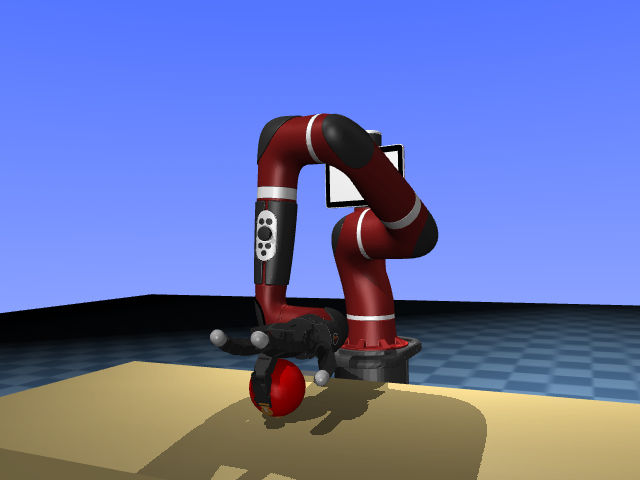

In [ ]:
# Here are some flags you can set to visualize contact forces
# We suggest that you visualize the results of your grasp synthesis algorithm when debugging
# Visualize contact frames and forces, make body transparent
options = mj.MjvOption()
mj.mjv_defaultOption(options)
options.flags[mj.mjtVisFlag.mjVIS_CONTACTPOINT] = True
options.flags[mj.mjtVisFlag.mjVIS_CONTACTFORCE] = False
options.flags[mj.mjtVisFlag.mjVIS_TRANSPARENT] = False

# tweak scales of contact visualization elements
physics.model.ptr.vis.scale.contactwidth = 0.1
physics.model.ptr.vis.scale.contactheight = 0.03
physics.model.ptr.vis.scale.forcewidth = 0.05
physics.model.ptr.vis.map.force = 0.05

# Take the full qpos for our force closure grasp for later
grasp_q = physics.data.qpos.copy()

# Show hand in grasp configuration
with mj.Renderer(physics.model.ptr, 480, 640) as renderer:
    renderer.update_scene(physics.data.ptr, "camera_1", options)
    frame = renderer.render()
    media.show_image(renderer.render())

In [ ]:
# Here's some code to run a control loop in MuJoCo
# This is just an initial suggestion, so feel free to change anything about it

duration = 5
framerate = 30
dt = 1 / (duration * framerate)
video = []
n_steps = 200

# allocate
sim_time = np.zeros(n_steps)
ncon = np.zeros(n_steps)
force = np.zeros((n_steps,3))
forcetorque = np.zeros(6)

physics.reset()

# Initialize state
physics.data.qpos[:] = grasp_q
physics.data.qvel[:] = 0
physics.forward()
finger_joints_slice = slice(14, 30)

# Run control loop
with mj.Renderer(physics.model.ptr, 480, 640) as renderer:
    for i in range(n_steps):
        while physics.data.time * framerate < i:
            # Control robot and collect data for plotting
            #YOUR CODE HERE

            physics.step()
        # Render scene, feel free to change camera
        renderer.update_scene(physics.data.ptr, "camera_1", options)
        frame = renderer.render()
        video.append(frame)

# Plot
# This is just to serve as an example for plotting. You'll likely have to make some changes for the deliverables
_, ax = plt.subplots(3, 1, sharex=True, figsize=(10, 10))

lines = ax[0].plot(sim_time, force)
ax[0].set_title('Contact force')
ax[0].set_ylabel('Newton')
ax[0].legend(list(lines), ('normal z', 'friction x', 'friction y'))
ax[1].plot(sim_time, ncon)
ax[1].set_title('Number of contacts')
ax[1].set_yticks(range(10))

ax[2].plot(sim_time, force[:,0])
ax[2].set_yscale('log')
ax[2].set_title('Normal (z) force - log scale')
ax[2].set_ylabel('Newton')


PhysicsError: Physics state is invalid. Warning(s) raised: mjWARN_BADQACC

In [ ]:
# Display video
media.show_video(video, fps=30)

This browser does not support the video tag.
